# EIT Forward Problem — 2-D Circular Domain

This notebook walks through every step of a **2-D Electrical Impedance Tomography (EIT) forward simulation** using `eitkit`:

1. Build a quality triangular mesh and place 16 electrodes
2. Define an adjacent-drive measurement protocol
3. Create synthetic conductivity phantoms
4. Solve the forward problem → difference voltages δV
5. Compute the Jacobian (sensitivity matrix)

All components are from `eitkit` Phase 1 (pure Python / NumPy / SciPy).

In [11]:
# Install eitkit into the active kernel (run once)
import subprocess, sys, pathlib
repo_root = pathlib.Path.cwd().parent          # examples/ → repo root
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_root)])
print("eitkit installed")

eitkit installed


In [12]:
# ── 8a: Imports ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Mesh
from eitkit.mesh import make_circle_mesh, place_electrodes

# Protocol
from eitkit.protocol import adjacent_pattern, measurement_pairs, add_noise

# Forward / Jacobian
from eitkit.forward import simulate, assemble_K, compute_jacobian

# Utils
from eitkit.utils import make_phantom, plot_mesh, plot_conductivity, plot_voltages

print("eitkit imported — ready")

eitkit imported — ready


## Step 1 — Build Mesh and Place Electrodes

We triangulate the unit disk using the **DistMesh** algorithm (spring-relaxation on a
hex-grid seed) and place **16 equally-spaced electrodes** on the boundary.

* `make_circle_mesh(n_electrodes, h0, seed)` — `h0` controls element size (≈ edge length)
* `place_electrodes(mesh, n_electrodes)` — returns `ElectrodeConfig` with boundary-node indices

Nodes      : 747
Elements   : 1458
Electrodes : 16  (node indices: [731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746])


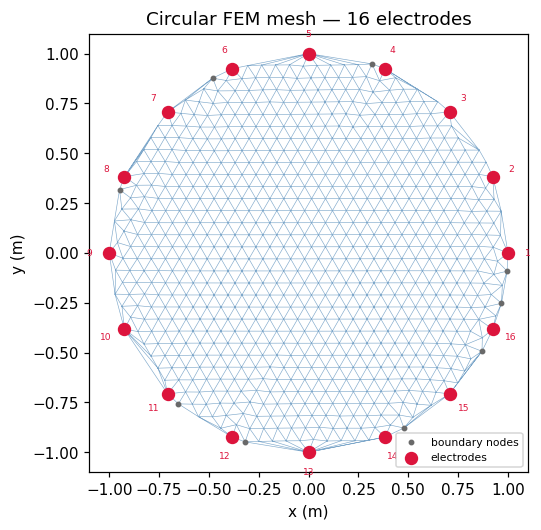

In [13]:
# ── 8b: Mesh + Electrodes ─────────────────────────────────────────────────
N_ELEC = 16
mesh = make_circle_mesh(n_electrodes=N_ELEC, h0=0.07, seed=42)
ec   = place_electrodes(mesh, N_ELEC)

print(f"Nodes      : {len(mesh.nodes)}")
print(f"Elements   : {len(mesh.elements)}")
print(f"Electrodes : {N_ELEC}  (node indices: {ec.node_indices.tolist()})")

fig, ax = plot_mesh(mesh, elec_config=ec, title="Circular FEM mesh — 16 electrodes")
plt.tight_layout()
plt.show()

## Step 2 — Measurement Protocol

EIT uses **adjacent current injection** (current between electrode $i$ and $i+1$) and
records voltages on all remaining electrode pairs.

* `adjacent_pattern(n)` — returns list of `(src, sink)` drive pairs (skips overlapping pairs)
* `measurement_pairs(n)` — returns list of `(+, −)` measurement pairs per drive step
* Total measurements = $L \times (L-3)$ where $L$ = number of electrodes

In [14]:
# ── 8c: Measurement Protocol ──────────────────────────────────────────────
drive_pairs = adjacent_pattern(N_ELEC)
meas_pairs  = measurement_pairs(N_ELEC)   # shape (L*(L-3), 3): [drive_step, +elec, -elec]

total         = len(meas_pairs)           # L*(L-3)
meas_per_step = N_ELEC - 3               # 13 for L=16

print(f"Drive pairs         : {len(drive_pairs)}")
print(f"Meas per drive step : {meas_per_step}")
print(f"Total measurements  : {total}  (= {N_ELEC} × {meas_per_step})")
print()
print("First 3 drive pairs:", drive_pairs[:3].tolist())
print("First 3 meas rows [drive_step, +, -]:", meas_pairs[:3].tolist())

Drive pairs         : 16
Meas per drive step : 13
Total measurements  : 208  (= 16 × 13)

First 3 drive pairs: [[0, 1], [1, 2], [2, 3]]
First 3 meas rows [drive_step, +, -]: [[0, 2, 3], [0, 3, 4], [0, 4, 5]]


## Step 3 — Conductivity Phantoms

We define three synthetic conductivity distributions on the mesh:

| Phantom | Description |
|---------|-------------|
| **A — Homogeneous** | Uniform $\sigma=1$ S/m background |
| **B — Circle** | Single high-conductivity circular inclusion ($\sigma=3$) |
| **C — Two shapes** | Ellipse ($\sigma=0.3$, low) + rectangle ($\sigma=4$, high) |

The `make_phantom` helper assigns one conductivity value per element.

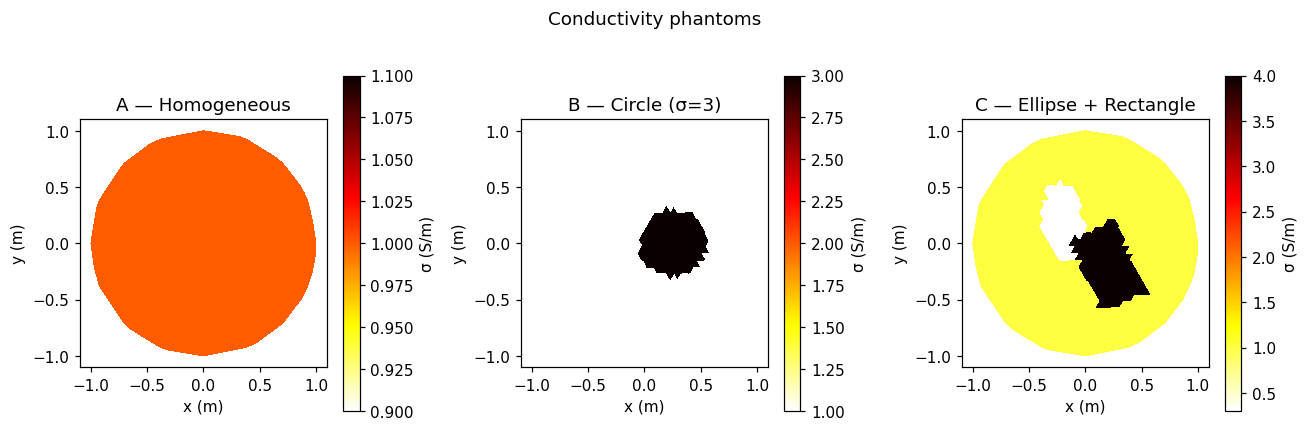

In [15]:
# ── 8d: Conductivity Phantoms ─────────────────────────────────────────────

# A — homogeneous reference
sigma_ref = make_phantom(mesh, inclusions=[])

# B — single circular inclusion (high conductivity)
sigma_circle = make_phantom(
    mesh,
    inclusions=[{"shape": "circle", "cx": 0.25, "cy": 0.0, "r": 0.30, "sigma": 3.0}],
)

# C — ellipse (low) + rectangle (high)
sigma_two = make_phantom(
    mesh,
    inclusions=[
        {"shape": "ellipse",    "cx": -0.2, "cy":  0.2, "a": 0.35, "b": 0.18, "theta": 30.0, "sigma": 0.3},
        {"shape": "rectangle",  "cx":  0.2, "cy": -0.2, "w": 0.35, "h": 0.22, "theta": -20.0, "sigma": 4.0},
    ],
)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax_, sigma_, title_ in zip(
    axes,
    [sigma_ref, sigma_circle, sigma_two],
    ["A — Homogeneous", "B — Circle (σ=3)", "C — Ellipse + Rectangle"],
):
    plot_conductivity(mesh, sigma_, ax=ax_, title=title_, show_mesh=False)

plt.suptitle("Conductivity phantoms", y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

## Step 4 — Forward Simulation (Difference EIT)

`simulate(mesh, ec, drive_pairs, meas_pairs, sigma)` solves the FEM forward problem for
every drive step and returns voltage measurements $V$.

**Difference EIT**: We compute $\delta V = V(\sigma) - V(\sigma_{\text{ref}})$.  
Only changes relative to the homogeneous background are shown — this cancels
electrode-contact artefacts present in both measurements.

The resulting matrix is reshaped to *(n_drive × n_meas_per_step)* and displayed as a
heatmap. The **hot diagonal** pattern (largest signals near the injection electrodes) is
the expected signature of a healthy EIT system.

Measurement vector length : 208
|δV| circle  — max=0.0067  rms=0.0030
|δV| two-inc — max=0.0143  rms=0.0052


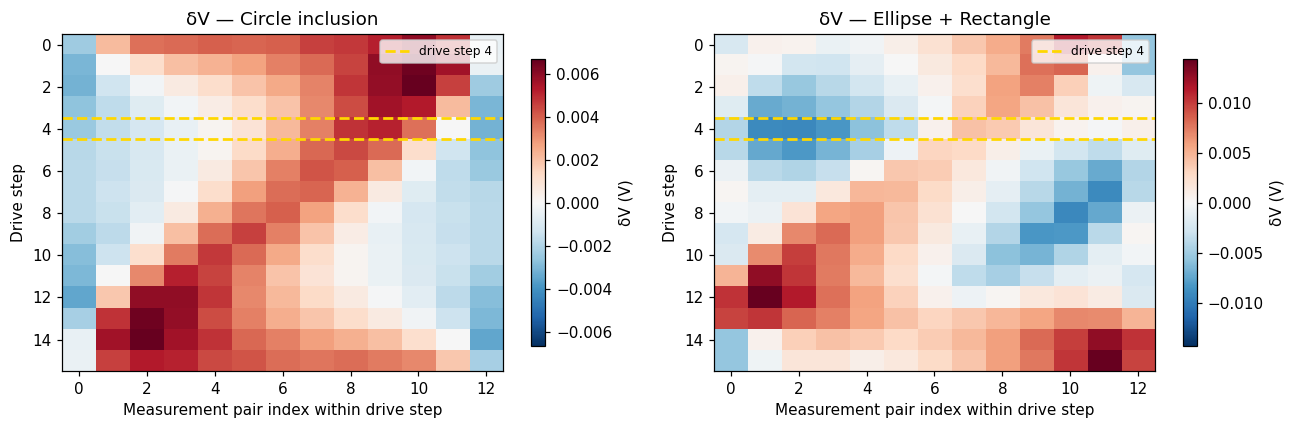

In [16]:
# ── 8e: Forward Simulation ────────────────────────────────────────────────
# simulate(mesh, ec, sigma, drive_pairs, meas_pairs) → dV  shape (P,)
V_ref    = simulate(mesh, ec, sigma_ref,    drive_pairs, meas_pairs)
V_circle = simulate(mesh, ec, sigma_circle, drive_pairs, meas_pairs)
V_two    = simulate(mesh, ec, sigma_two,    drive_pairs, meas_pairs)

dV_circle = V_circle - V_ref
dV_two    = V_two    - V_ref

print(f"Measurement vector length : {len(V_ref)}")
print(f"|δV| circle  — max={np.abs(dV_circle).max():.4f}  rms={np.sqrt(np.mean(dV_circle**2)):.4f}")
print(f"|δV| two-inc — max={np.abs(dV_two).max():.4f}  rms={np.sqrt(np.mean(dV_two**2)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_voltages(meas_pairs, dV_circle, n_electrodes=N_ELEC, ax=axes[0],
              title="δV — Circle inclusion", highlight_drive=4)
plot_voltages(meas_pairs, dV_two,    n_electrodes=N_ELEC, ax=axes[1],
              title="δV — Ellipse + Rectangle", highlight_drive=4)
plt.tight_layout()
plt.show()

## Step 5 — Jacobian & Sensitivity Map

The **Jacobian** $J \in \mathbb{R}^{M \times E}$ maps a small conductivity perturbation
$\delta\sigma$ on each element to the resulting voltage change $\delta V$:

$$\delta V \approx J\, \delta\sigma$$

It is computed via the **adjoint method** — $L$ forward solves + $L$ adjoint solves,
where $L$ = number of drive steps.

The **sensitivity** of measurement $m$ to element $e$ is $|J_{me}|$.
Summing over all measurements gives the overall sensitivity map:

$$S_e = \sum_m J_{me}^2 \quad\text{(diagonal of } J^\top J \text{)}$$

High sensitivity near the electrodes and lower sensitivity in the centre is the expected
pattern for a circular domain.

Computing Jacobian (adjoint method) …
J shape: (208, 1458)  (measurements × elements)


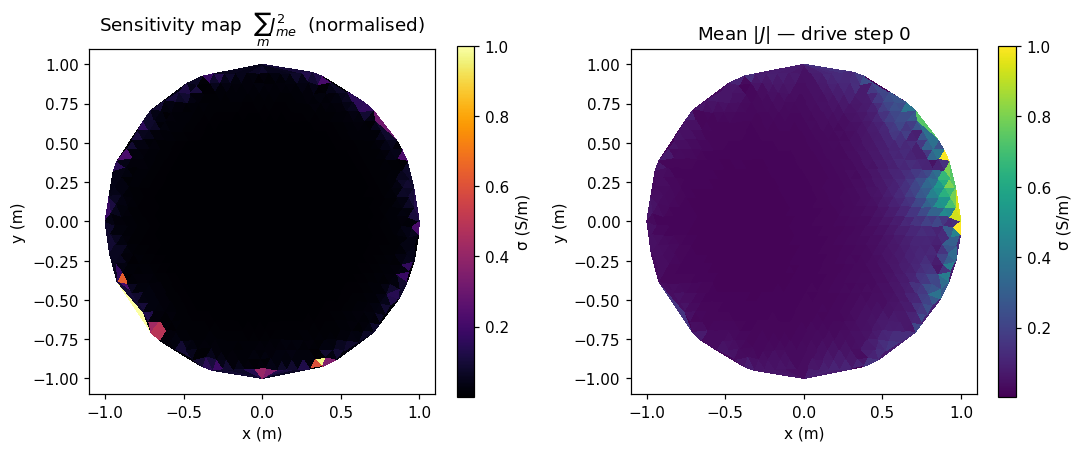

: 

In [ ]:
# ── 8f: Jacobian & Sensitivity ────────────────────────────────────────────
print("Computing Jacobian (adjoint method) …")
# compute_jacobian(mesh, ec, sigma, drive_pairs, meas_pairs)
J = compute_jacobian(mesh, ec, sigma_ref, drive_pairs, meas_pairs)
print(f"J shape: {J.shape}  (measurements × elements)")

# Sensitivity = diagonal of J^T J  (sum of squared sensitivities per element)
sensitivity = np.einsum("me,me->e", J, J)          # equivalent to (J**2).sum(axis=0)

# Normalise to [0, 1] for display
sensitivity_norm = sensitivity / sensitivity.max()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_conductivity(mesh, sensitivity_norm, ax=axes[0],
                  cmap="inferno", title="Sensitivity map  $\\sum_m J_{me}^2$  (normalised)",
                  show_mesh=False)

# Also show mean |J| over first drive step
n_meas_step = N_ELEC - 3
J_row0 = np.abs(J[:n_meas_step, :]).mean(axis=0)
J_row0_norm = J_row0 / J_row0.max()
plot_conductivity(mesh, J_row0_norm, ax=axes[1],
                  cmap="viridis", title="Mean $|J|$ — drive step 0",
                  show_mesh=False)

plt.tight_layout()
plt.show()

## Summary

In this notebook we walked through the complete **EIT forward problem** using `eitkit`:

| Step | Module | Key function |
|------|--------|-------------|
| 1 | `eitkit.mesh` | `make_circle_mesh`, `place_electrodes` |
| 2 | `eitkit.protocol` | `adjacent_pattern`, `measurement_pairs` |
| 3 | `eitkit.utils` | `make_phantom` |
| 4 | `eitkit.forward` | `simulate` |
| 5 | `eitkit.forward` | `compute_jacobian` |

### What we observed

* The **heatmap diagonal** in the difference-voltage plots confirms that the largest
  signal changes occur near the active injection electrodes — a hallmark of EIT physics.
* The **sensitivity map** (diagonal of $J^\top J$) shows high sensitivity near the
  boundary and lower sensitivity in the domain centre, consistent with theory.
* Adding noise via `add_noise(V, snr_db=40)` is straightforward and can be used to
  simulate realistic measurement conditions.

### Next steps

* **Inverse problem** (`02_inverse_tikhonov.ipynb`) — reconstruct $\sigma$ from $\delta V$
  using Tikhonov regularisation: $\hat{\sigma} = (J^\top J + \lambda I)^{-1} J^\top \delta V$
* **Noise robustness** — explore the effect of SNR on reconstruction quality
* **3-D extension** — replace `make_circle_mesh` with a tetrahedral mesh generator